In [18]:
!git clone https://github.com/Jakobovski/free-spoken-digit-dataset.git

fatal: destination path 'free-spoken-digit-dataset' already exists and is not an empty directory.


In [19]:
import os
import glob
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Audio
from scipy.signal import hilbert
from scipy.io import wavfile
import librosa

dataPath = "free-spoken-digit-dataset/recordings"
fileList = sorted(glob.glob(os.path.join(dataPath, "*.wav")))

signals = []
labels = []
sample_rates = []
filenames = []

for file in fileList:
    sr, signal = wavfile.read(file)
    label = int(os.path.basename(file).split("_")[0])

    signals.append(signal)
    labels.append(label)
    sample_rates.append(sr)
    filenames.append(os.path.basename(file))

print("Loaded", len(signals), "audio files")
print("Unique sample rates:", set(sample_rates))


Loaded 3000 audio files
Unique sample rates: {8000}


Play one recording

In [20]:
i = 2999
print("File:", filenames[i])
print("Digit:", labels[i])
Audio(signals[i], rate=sample_rates[i])


File: 9_yweweler_9.wav
Digit: 9


Plot one digit

In [22]:
# Find the first recording whose label is 2
i = labels.index(2)

print("Index:", i)
print("Digit:", labels[i])
print("Filename:", filenames[i])

Index: 600
Digit: 2
Filename: 2_george_0.wav


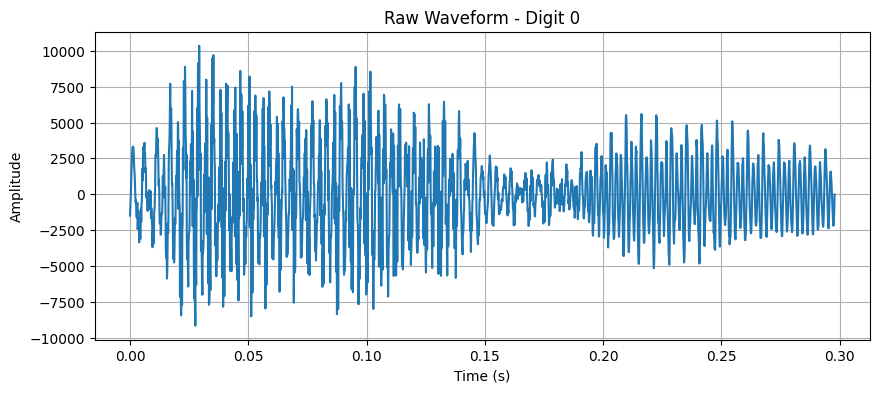

In [23]:
i = 0

x_raw = np.array(signals[i], dtype=float)
sr = sample_rates[i]
t_raw = np.arange(len(x_raw)) / sr

plt.figure(figsize=(10, 4))
plt.plot(t_raw, x_raw)
plt.title(f"Raw Waveform - Digit {labels[i]}")
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.grid(True)
plt.show()


Preprocessing

In [24]:
def preprocessSignal(signal, sr=8000, top_db=20):
    sig = np.array(signal, dtype=float)

    # Remove DC offset
    sig = sig - np.mean(sig)

    # Normalize amplitude
    max_val = np.max(np.abs(sig))
    if max_val > 0:
        sig = sig / max_val

    # Trim leading and trailing silence
    signalTrimmed, _ = librosa.effects.trim(sig, top_db=top_db)

    return signalTrimmed


In [25]:
processed_signals = [preprocessSignal(sig, sr=8000, top_db=20) for sig in signals]

print("Original number of signals:", len(signals))
print("Processed number of signals:", len(processed_signals))
print("Example lengths:", len(signals[0]), "->", len(processed_signals[0]))


Original number of signals: 3000
Processed number of signals: 3000
Example lengths: 2384 -> 2384


1.Temporal Envelope

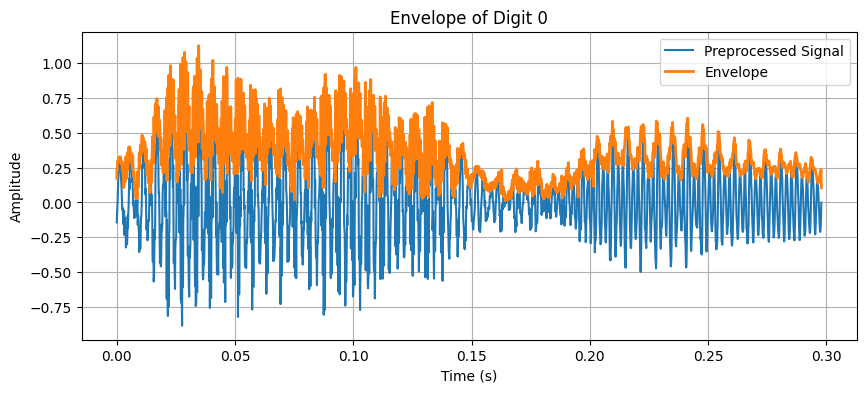

In [26]:
i = 0

x = np.array(processed_signals[i], dtype=float)
sr = sample_rates[i]
t = np.arange(len(x)) / sr

analyticSignal = hilbert(x)
envelope = np.abs(analyticSignal)

plt.figure(figsize=(10, 4))
plt.plot(t, x, label="Preprocessed Signal")
plt.plot(t, envelope, label="Envelope", linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Envelope of Digit {labels[i]}")
plt.grid(True)
plt.legend()
plt.show()


2.Zero-crossing rate

Zero-crossings number: 382
Zero-crossing rate: 0.16023489932885907


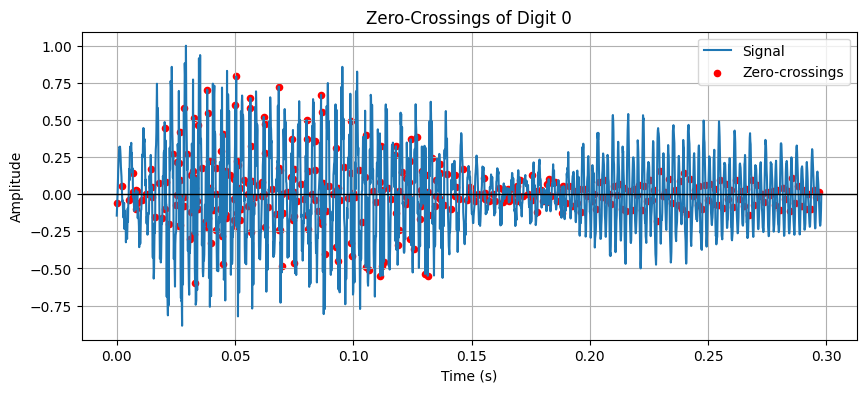

In [27]:
i = 0

x = np.array(processed_signals[i], dtype=float)
sr = sample_rates[i]
t = np.arange(len(x)) / sr

x_sign = np.sign(x)
x_sign[x_sign == 0] = 1
zeroCrossings = np.where(np.diff(x_sign) != 0)[0]

zcr = len(zeroCrossings) / len(x)

print("Zero-crossings number:", len(zeroCrossings))
print("Zero-crossing rate:", zcr)

plt.figure(figsize=(10, 4))
plt.plot(t, x, label="Signal")
plt.scatter(t[zeroCrossings], x[zeroCrossings],
            color="red", s=20, label="Zero-crossings")
plt.axhline(0, color="black", linewidth=1)
plt.xlabel("Time (s)")
plt.ylabel("Amplitude")
plt.title(f"Zero-Crossings of Digit {labels[i]}")
plt.grid(True)
plt.legend()
plt.show()


3.RMS short-time energy

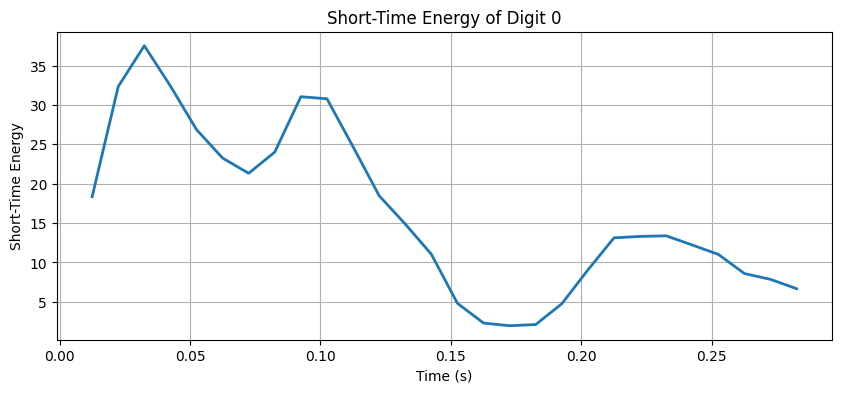

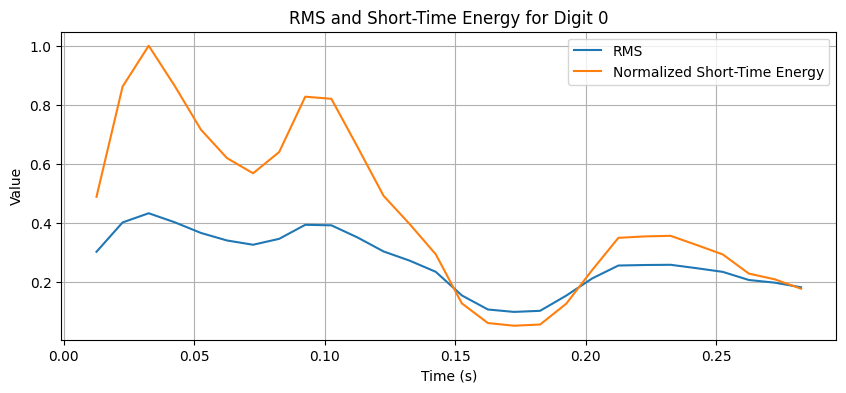

In [9]:
i = 0

x = np.array(processed_signals[i], dtype=float)
sr = sample_rates[i]
t = np.arange(len(x)) / sr

xFloat = x.astype(float)

if np.max(np.abs(xFloat)) > 1:
    xFloat = xFloat / np.max(np.abs(xFloat))

frameLength = int(0.025 * sr)   # 25 ms
hopLength = int(0.010 * sr)     # 10 ms

rmsValues = []
energyValues = []
frameTimes = []

for start in range(0, len(xFloat) - frameLength, hopLength):
    frame = xFloat[start:start + frameLength]

    energy = np.sum(frame ** 2)
    rms = np.sqrt(np.mean(frame ** 2))

    energyValues.append(energy)
    rmsValues.append(rms)
    frameTimes.append((start + frameLength / 2) / sr)

rmsValues = np.array(rmsValues)
energyValues = np.array(energyValues)
frameTimes = np.array(frameTimes)

plt.figure(figsize=(10, 4))
plt.plot(frameTimes, energyValues, linewidth=2)
plt.xlabel("Time (s)")
plt.ylabel("Short-Time Energy")
plt.title(f"Short-Time Energy of Digit {labels[i]}")
plt.grid(True)
plt.show()

energyNormalized = energyValues / np.max(energyValues)

plt.figure(figsize=(10, 4))
plt.plot(frameTimes, rmsValues, label="RMS")
plt.plot(frameTimes, energyNormalized, label="Normalized Short-Time Energy")
plt.xlabel("Time (s)")
plt.ylabel("Value")
plt.title(f"RMS and Short-Time Energy for Digit {labels[i]}")
plt.grid(True)
plt.legend()
plt.show()


4.Autocorrelation Coefficients

Autocorrelation coefficients:
[ 1.          0.75068782  0.64140732  0.56893837  0.38432306  0.17067334
 -0.17556248 -0.27015751 -0.41089674 -0.57690046 -0.70814933 -0.68595647
 -0.55859286 -0.57037424 -0.45440895 -0.28755932 -0.10082318  0.00652929
  0.07476743  0.26060966  0.3143963   0.33957769  0.35191672  0.35615533
  0.3683012   0.27175242  0.24811097  0.21349765  0.1577059   0.08876933
  0.01180674  0.01066462 -0.09988283 -0.17705392 -0.22206647 -0.29527327
 -0.34955799 -0.44408874 -0.42553883 -0.43427978 -0.4187239  -0.35946117
 -0.26598391 -0.07245782  0.00764889  0.19991943  0.36514711  0.51968084
  0.65153858  0.62722598]


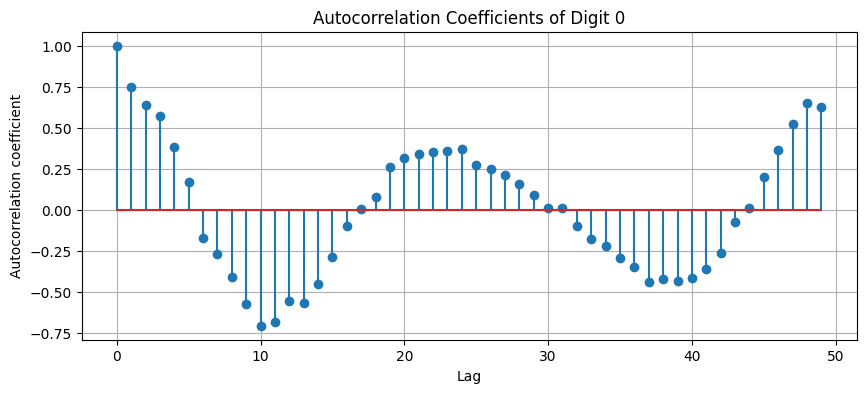

In [10]:
i = 0

x = np.array(processed_signals[i], dtype=float)
sr = sample_rates[i]

x_float = x.astype(float)

if np.max(np.abs(x_float)) > 1:
    x_float = x_float / np.max(np.abs(x_float))

x_float = x_float - np.mean(x_float)

autocorr = np.correlate(x_float, x_float, mode="full")
autocorr = autocorr[len(autocorr)//2:]

autocorr = autocorr / autocorr[0]

numCoeffs = 50
autoCoeffs = autocorr[:numCoeffs]

print("Autocorrelation coefficients:")
print(autoCoeffs)

lags = np.arange(numCoeffs)

plt.figure(figsize=(10, 4))
plt.stem(lags, autoCoeffs)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation coefficient")
plt.title(f"Autocorrelation Coefficients of Digit {labels[i]}")
plt.grid(True)
plt.show()


Features Matrix

In [11]:
def extract_features(signal, sr=8000, num_autocorr_coeffs=50):
    x = np.array(signal).astype(float)

    if np.max(np.abs(x)) > 1:
        x = x / np.max(np.abs(x))

    x = x - np.mean(x)

    x_sign = np.sign(x)
    x_sign[x_sign == 0] = 1
    zero_crossings = np.where(np.diff(x_sign) != 0)[0]
    zcr = len(zero_crossings) / len(x)

    frame_length = int(0.025 * sr)   # 25 ms
    hop_length = int(0.010 * sr)     # 10 ms

    rms_values = []
    energy_values = []

    for start in range(0, len(x) - frame_length, hop_length):
        frame = x[start:start + frame_length]
        energy = np.sum(frame ** 2)
        rms = np.sqrt(np.mean(frame ** 2))

        energy_values.append(energy)
        rms_values.append(rms)

    rms_values = np.array(rms_values)
    energy_values = np.array(energy_values)

    if len(rms_values) == 0:
        rms_mean = rms_std = rms_max = 0
        energy_mean = energy_std = energy_max = 0
    else:
        rms_mean = np.mean(rms_values)
        rms_std = np.std(rms_values)
        rms_max = np.max(rms_values)

        energy_mean = np.mean(energy_values)
        energy_std = np.std(energy_values)
        energy_max = np.max(energy_values)

    autocorr = np.correlate(x, x, mode="full")
    autocorr = autocorr[len(autocorr)//2:]

    if autocorr[0] != 0:
        autocorr = autocorr / autocorr[0]

    autocorr_coeffs = autocorr[:num_autocorr_coeffs]

    if len(autocorr_coeffs) < num_autocorr_coeffs:
        autocorr_coeffs = np.pad(
            autocorr_coeffs,
            (0, num_autocorr_coeffs - len(autocorr_coeffs))
        )

    feature_vector = np.concatenate([
        [zcr],
        [rms_mean, rms_std, rms_max],
        [energy_mean, energy_std, energy_max],
        autocorr_coeffs
    ])

    return feature_vector


In [12]:
X = []

for sig in processed_signals:
    features = extract_features(sig, sr=8000, num_autocorr_coeffs=50)
    X.append(features)

X = np.array(X)
y = np.array(labels)

print("Feature matrix shape:", X.shape)
print("Labels shape:", y.shape)


Feature matrix shape: (3000, 57)
Labels shape: (3000,)
